# LeetCode #36: Valid Sudoku

https://leetcode.com/problems/valid-sudoku/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (3-pass)** | $O(1)$ | $O(1)$ |
| **Single-pass Hash Set** ★ | $O(1)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (3-pass)
Iterate the board three separate times: once to validate all rows, once for all columns, and once for all nine 3x3 boxes. Each pass checks for duplicate digits using a temporary set that resets between groups. Correct but wasteful — three full scans of 81 cells.

### Optimal: Single-pass Hash Set ★
Visit each cell exactly once. For every non-dot cell at `(r, c)` with value `v`, encode its membership in three contexts as string keys — `"row-r-v"`, `"col-c-v"`, and `"box-(r/3)-(c/3)-v"` — and attempt to insert all three into a single global `HashSet`. If any `Add` fails (key already present), a duplicate exists; return false immediately. Otherwise return true after visiting all 81 cells.

**Why this is better than Brute Force:** One pass instead of three — the same $O(81)$ constant work, but with early exit on the first conflict and no per-group set resets.

**Constraints:**
* `board.length == 9`
* `board[i].length == 9`
* `board[i][j]` is a digit `'1'`–`'9'` or `'.'`

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsValidSudoku(char[][] board) {
        var seen = new HashSet<string>();
        for (int r = 0; r < 9; r++) {
            for (int c = 0; c < 9; c++) {
                char ch = board[r][c];
                if (ch == '.') continue;
                // Encode position context into string keys to detect duplicates across all three constraints
                string row = $"row-{r}-{ch}";
                string col = $"col-{c}-{ch}";
                string box = $"box-{r/3}-{c/3}-{ch}";
                if (!seen.Add(row) || !seen.Add(col) || !seen.Add(box))
                    return false;
            }
        }
        return true;
    }
}

### Python

In [ ]:
class Solution:
    def isValidSudoku(self, board: list[list[str]]) -> bool:
        seen = set()
        for r in range(9):
            for c in range(9):
                ch = board[r][c]
                if ch == '.':
                    continue
                # Encode position context as tuples to detect duplicates across all three constraints
                row_key = ('row', r, ch)
                col_key = ('col', c, ch)
                box_key = ('box', r // 3, c // 3, ch)
                for key in (row_key, col_key, box_key):
                    if key in seen:
                        return False
                    seen.add(key)
        return True

### Go

In [ ]:
func isValidSudoku(board [][]byte) bool {
    seen := make(map[string]bool)
    for r := 0; r < 9; r++ {
        for c := 0; c < 9; c++ {
            ch := board[r][c]
            if ch == '.' {
                continue
            }
            // Encode position context into string keys to detect duplicates across all three constraints
            keys := []string{
                fmt.Sprintf("row-%d-%c", r, ch),
                fmt.Sprintf("col-%d-%c", c, ch),
                fmt.Sprintf("box-%d-%d-%c", r/3, c/3, ch),
            }
            for _, k := range keys {
                if seen[k] {
                    return false
                }
                seen[k] = true
            }
        }
    }
    return true
}

### Rust

In [ ]:
use std::collections::HashSet;

impl Solution {
    pub fn is_valid_sudoku(board: Vec<Vec<char>>) -> bool {
        let mut seen = HashSet::new();
        for r in 0..9 {
            for c in 0..9 {
                let ch = board[r][c];
                if ch == '.' { continue; }
                // Encode position context into string keys to detect duplicates across all three constraints
                let keys = [
                    format!("row-{}-{}", r, ch),
                    format!("col-{}-{}", c, ch),
                    format!("box-{}-{}-{}", r / 3, c / 3, ch),
                ];
                for k in &keys {
                    if !seen.insert(k.clone()) { return false; }
                }
            }
        }
        true
    }
}

## Example Scenarios

**1. Common Case**
**Input:** board[0] = ["5","3",".",".","7",".",".",".","."], board[1][2] = "9"
Cell (0,0)='5' inserts row-0-5, col-0-5, box-0-0-5. Cell (0,4)='7' inserts row-0-7, col-4-7, box-0-1-7 — different box. Each Add succeeds; board returns true.

**2. Slightly Complex**
**Input:** board[0][0]='8', board[3][3]='8'
Both cells contain '8', but their keys are fully disjoint: row-0-8 vs row-3-8, col-0-8 vs col-3-8, and box-0-0-8 vs box-1-1-8. No collision — the digit 8 occupies a unique row, column, and box in each case. Returns true.

**3. Edge Case: Time Factor**
**Input:** A completely filled, valid 9x9 board (all 81 cells are digits).
No cells are skipped (zero dot-checks short-circuit). The algorithm performs exactly $81 \times 3 = 243$ HashSet insertions — the maximum constant work. Despite touching every cell, runtime is still $O(1)$ because the board size is fixed at 81.

**4. Edge Case: Space Factor**
**Input:** Same fully filled valid board as above.
The HashSet grows to its maximum of 243 entries: $9 \times 9 + 9 \times 9 + 9 \times 9 = 243$ (rows + cols + boxes, each covering 9 digits). Because the board is always $9 \times 9$, the set is bounded by this constant — $O(1)$ space regardless of which cells are filled.

**5. Almost-Impossible but Plausible**
**Input:** board[0][0]='5', board[1][1]='5', all other cells are '.'
Cell (0,0) inserts row-0-5, col-0-5, and box-0-0-5 — all succeed. Cell (1,1) then inserts row-1-5 and col-1-5 successfully (different row and column), but tries to insert box-0-0-5, which already exists — both cells share the top-left $3 \times 3$ box. Add() fails, the function immediately returns false.

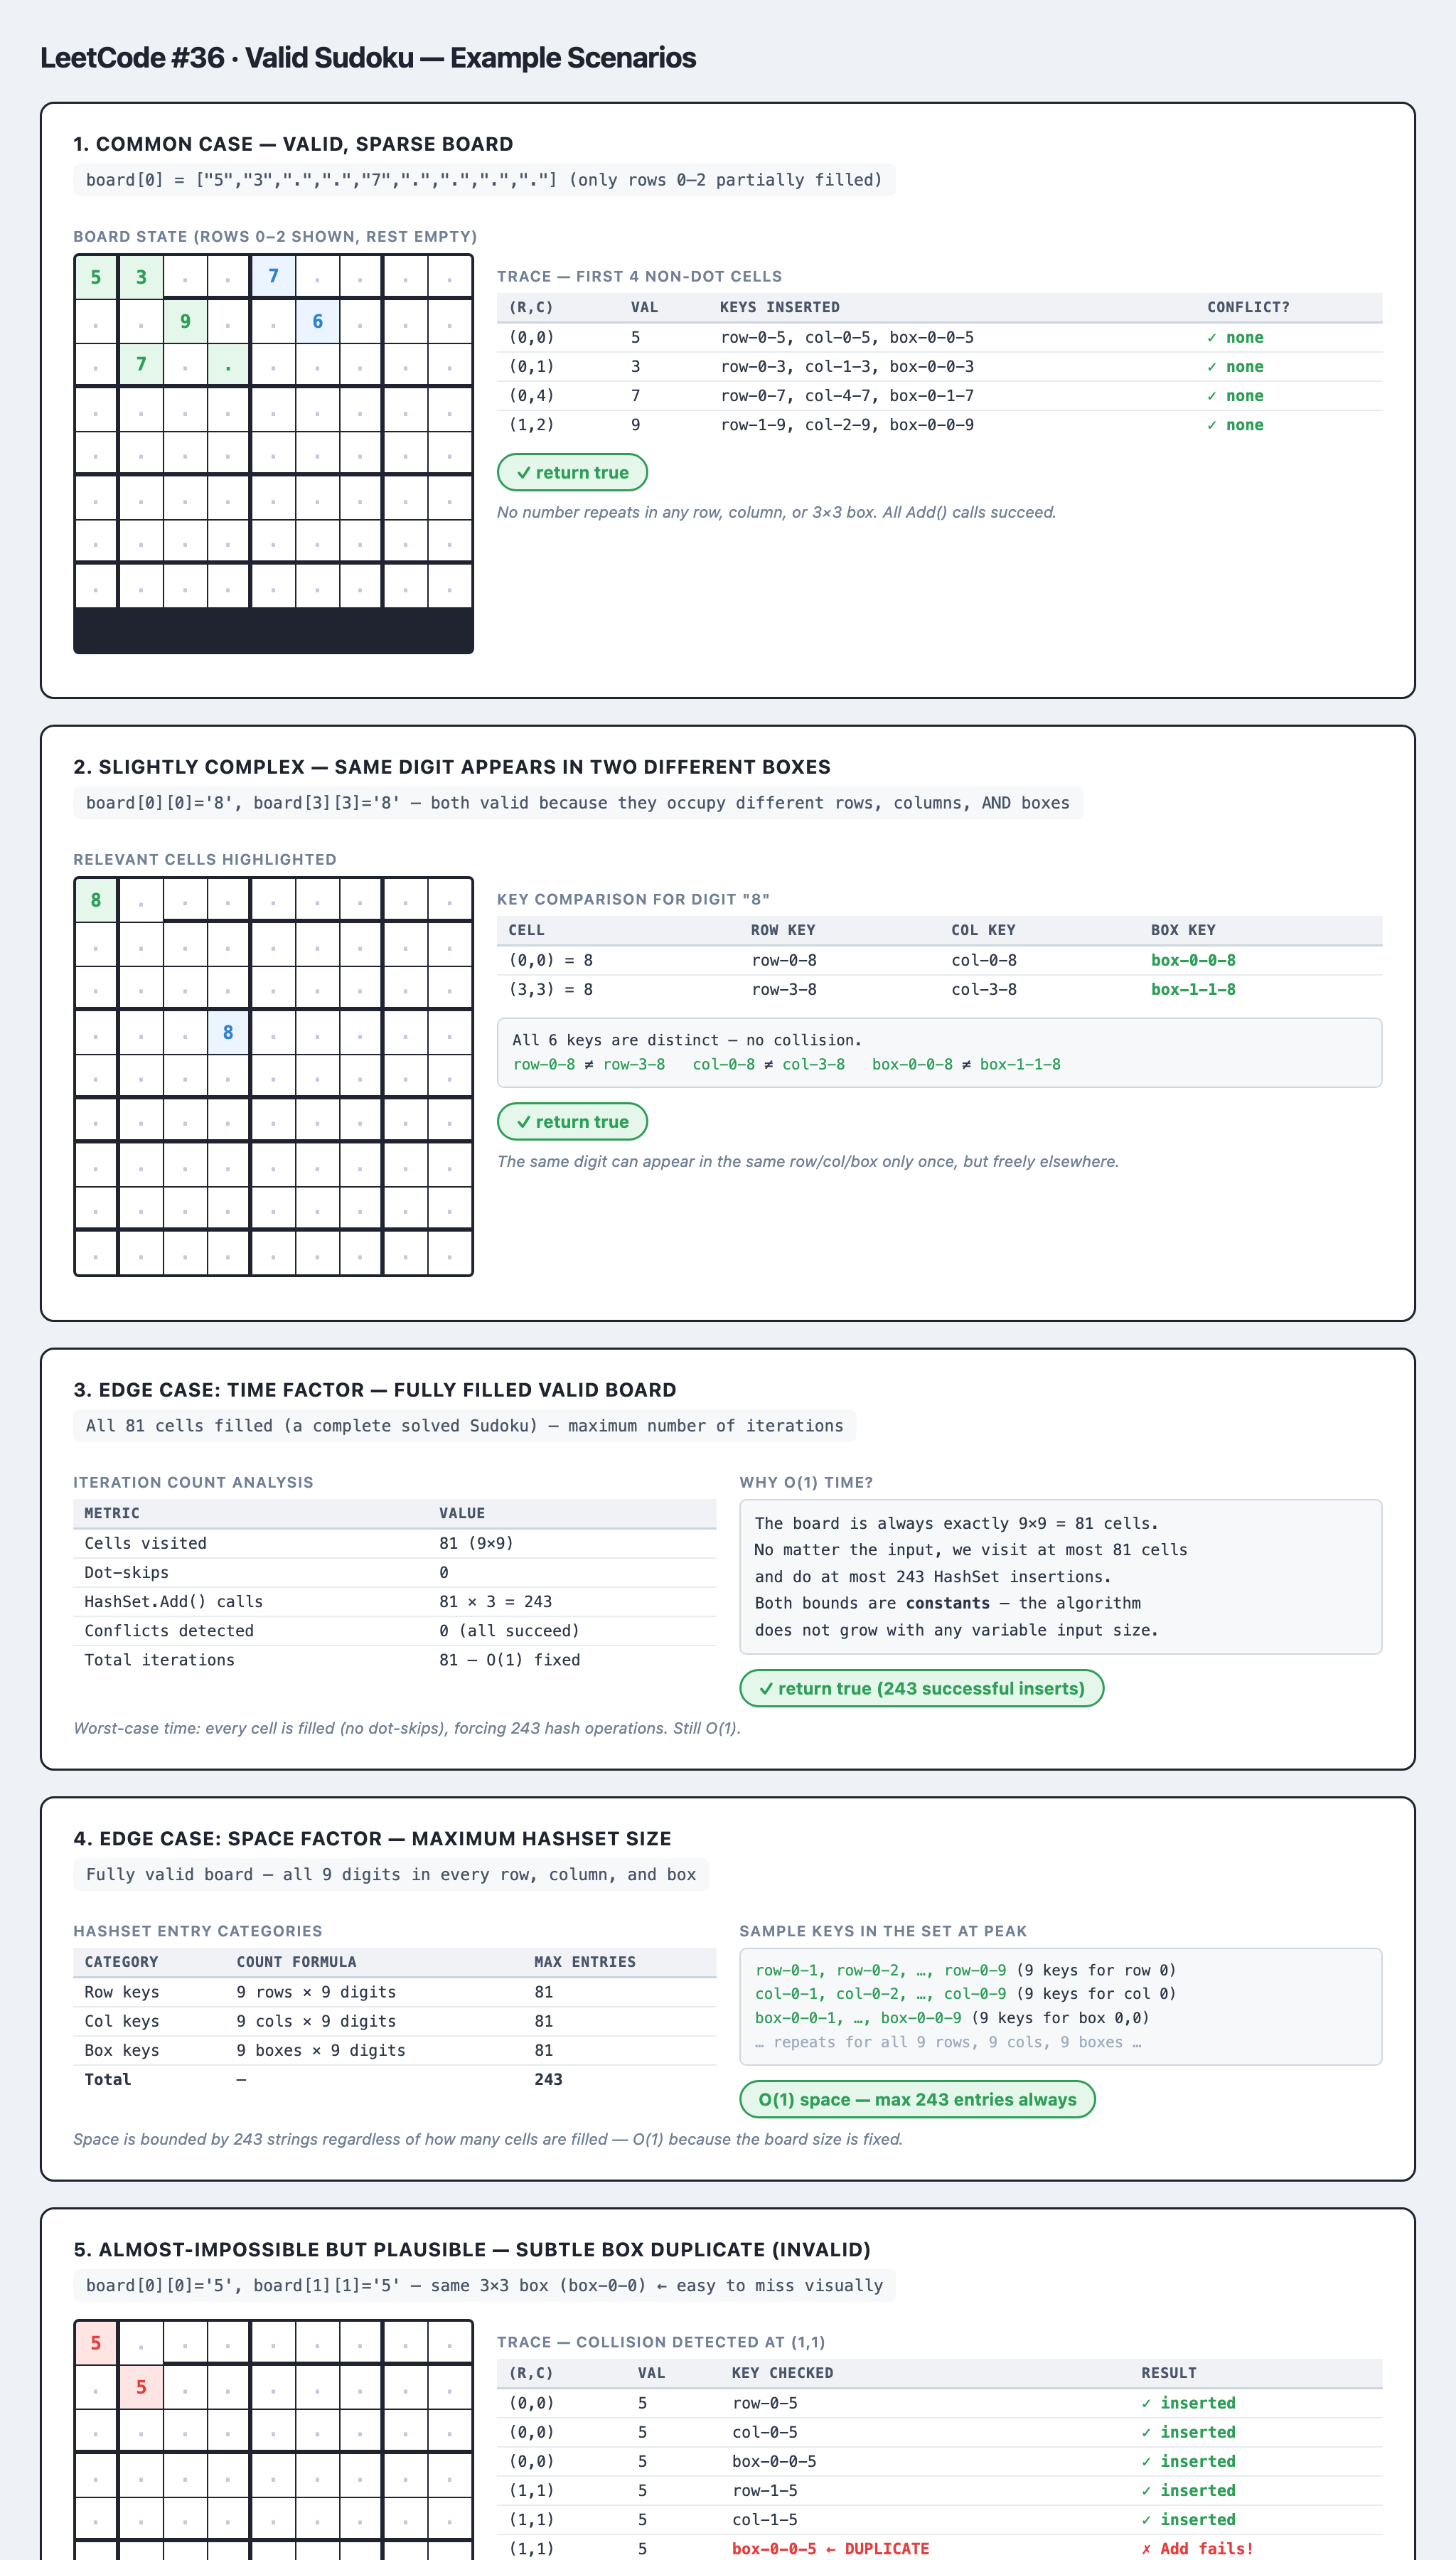